# DICOM Data Notes

This notebook provides an introduction to the DICOM data storage format, which is widely used in clinical practices for storing medical images.

## Data Sources

The data used in this notebook were retrieved from [Data sets | Aliza Medical Imaging](https://www.aliza-dicom-viewer.com/download/datasets)


In [1]:
from pathlib import Path

toshiba_aquilion_data = Path('.') / 'data' / 'Toshiba_Aquilion'

dicom_files = list(toshiba_aquilion_data.glob('*.dcm'))

In [2]:
from pathlib import Path

toshiba_aquilion_data = Path('.') / 'data' / 'ct_nonequi_tilt'

dicom_files = list(toshiba_aquilion_data.glob('*.dcm'))

In [ ]:
import matplotlib.pyplot as plt
from pydicom import dcmread

i_file = 10

try:
    dcm = dcmread(dicom_files[i_file])
except Exception as e:
    print(e)
    dcm = dcmread(dicom_files[i_file], force=True)
    dcm.is_little_endian = True
    dcm.is_implicit_VR = True
    dcm.fix_meta_info()

dcm

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 236
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.9.4245.9376602065817953863711582886823264673
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.9.4245.0.0.0.0.1.48.20
(0002, 0013) Implementation Version Name         SH: 'Aliza 1.48.20'
(0002, 0016) Source Application Entity Title     AE: 'ALIZAAE'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'ADD']
(0008, 0016) SOP Class UID                       UI: CT Image Storage
(0008, 0018) SOP Instance UID                    UI: 1

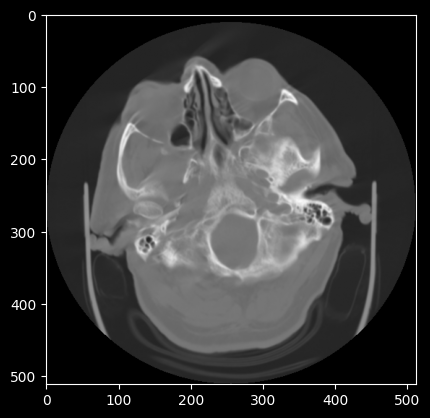

In [4]:
plt.imshow(dcm.pixel_array, cmap='gray')